# Końcowa ocena własnej sieci CustomCNN

Celem eksperymentu jest końcowa ocena własnej architektury CustomCNN w zadaniu klasyfikacji polskich znaków drogowych.

Na podstawie wcześniejszych eksperymentów wybrano następującą konfigurację końcową:

- własna sieć konwolucyjna `CustomCNN`,
- `WeightedRandomSampler`,
- augmentacja oświetleniowa,
- korekcja gamma γ = 1.5,
- funkcja straty Cross Entropy,
- 20 epok treningu,
- rozdzielczość wejściowa 224 × 224 piksele.

Konfiguracja augmentacji oświetleniowej obejmuje:

- zakres jasności: 0.3–1.3,
- zakres kontrastu: 0.8–1.2,
- prawdopodobieństwo zastosowania: 0.8.

Model został wcześniej wytrenowany i wybrany na podstawie zbioru treningowego oraz walidacyjnego. W tym notebooku nie jest prowadzony dalszy trening ani dostrajanie parametrów.

Końcowa ocena wykonywana jest na niezależnym zbiorze `test_final`.

Ocena obejmuje obraz oryginalny, trzy poziomy kontrolowanego zaciemnienia oraz trzy poziomy kontrolowanego zwiększenia jasności.

In [ ]:
from pathlib import Path
import sys
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image, ImageEnhance
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )
    
from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.preprocessing import (
    gamma_correction,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.custom_cnn import (
    CustomCNN,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)



set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)


HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)


CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "final_custom_cnn"
)


FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja finalnego pipeline'u

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 1e-3
RANDOM_SEED = 42
GAMMA_VALUE = 1.5

BRIGHTNESS_RANGE = (
    0.3,
    1.3,
)

CONTRAST_RANGE = (
    0.8,
    1.2,
)

AUGMENTATION_PROBABILITY = 0.8

BALANCING_STRATEGY = (
    "weighted_sampler"
)

LOSS_FUNCTION = (
    "CrossEntropyLoss"
)

MODEL_NAME = (
    "CustomCNN"
)

LIGHTING_VARIANTS = [
    "original",
    "dark_1",
    "dark_2",
    "dark_3",
    "bright_1",
    "bright_2",
    "bright_3",
]


CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "custom_cnn_ablation_sampler_lighting_gamma.pt"
)


print(
    "Model:",
    MODEL_NAME
)

print(
    "Input:",
    IMAGE_SIZE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Epochs:",
    EPOCHS
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Gamma:",
    GAMMA_VALUE
)

print(
    "Brightness range:",
    BRIGHTNESS_RANGE
)

print(
    "Contrast range:",
    CONTRAST_RANGE
)

print(
    "Augmentation probability:",
    AUGMENTATION_PROBABILITY
)

print(
    "Balancing:",
    BALANCING_STRATEGY
)

Model: CustomCNN
Input: 224
Batch size: 32
Epochs: 20
Learning rate: 0.001
Gamma: 1.5
Brightness range: (0.3, 1.3)
Contrast range: (0.8, 1.2)
Augmentation probability: 0.8
Balancing: weighted_sampler


## 2. Wczytanie manifestów danych

In [5]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Transformacja końcowa

Końcowy pipeline stosuje korekcję gamma γ = 1.5, zmianę rozdzielczości obrazu do 224 × 224 pikseli oraz normalizację wartości kanałów.

W przypadku kontrolowanych wariantów oświetlenia modyfikacja jasności jest wykonywana przed korekcją gamma.

In [6]:
normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


def build_final_eval_transform():

    return transforms.Compose(
        [
            transforms.Lambda(
                lambda image:
                gamma_correction(
                    image,
                    gamma=GAMMA_VALUE,
                )
            ),

            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )

## 4. DataLoader walidacyjny

Przed oceną niezależnego zbioru testowego sprawdzana jest skuteczność wybranego checkpointu na zbiorze walidacyjnym.

In [7]:
validation_dataset = (
    TrafficSignDataset(
        VALIDATION_PATH,
        class_to_idx,
        transform=(
            build_final_eval_transform()
        ),
    )
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


print(
    "VALIDATION:",
    len(validation_dataset)
)

VALIDATION: 2512


## 5. Utworzenie modelu CustomCNN

W końcowej ocenie wykorzystano własną architekturę CustomCNN opracowaną w ramach pracy.

Model zawiera cztery warstwy konwolucyjne z Batch Normalization i aktywacją ReLU. Po części konwolucyjnej zastosowano Adaptive Average Pooling, Dropout oraz końcową warstwę liniową dla 92 klas.

In [8]:
model = CustomCNN(
    num_classes=len(
        class_codes
    )
)


model = model.to(
    DEVICE
)


total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)


trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


print(
    "Model:",
    MODEL_NAME
)

print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "Liczba wszystkich parametrów:",
    total_parameters
)

print(
    "Liczba trenowalnych parametrów:",
    trainable_parameters
)

Model: CustomCNN
Liczba klas: 92
Liczba wszystkich parametrów: 413020
Liczba trenowalnych parametrów: 413020


## 6. Wczytanie wybranego checkpointu

Do końcowego testu wykorzystywany jest checkpoint wybranego wariantu `CustomCNN`.

In [9]:
print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

print(
    "Istnieje:",
    CHECKPOINT_PATH.exists()
)


if not CHECKPOINT_PATH.exists():

    raise FileNotFoundError(
        (
            "Nie znaleziono checkpointu:\n"
            f"{CHECKPOINT_PATH}\n\n"
            "Ustaw poprawną nazwę pliku "
            "checkpointu w CHECKPOINT_PATH."
        )
    )

Checkpoint: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\custom_cnn_ablation_sampler_lighting_gamma.pt
Istnieje: True


In [10]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)


if (
    isinstance(
        checkpoint,
        dict
    )
    and
    "model_state_dict"
    in checkpoint
):

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

else:

    model.load_state_dict(
        checkpoint
    )


model.eval()


print(
    "Checkpoint został poprawnie "
    "wczytany."
)

Checkpoint został poprawnie wczytany.


## 7. Standardowa skuteczność na zbiorze walidacyjnym

Przed przejściem do niezależnego zbioru testowego sprawdzana jest skuteczność wczytanego modelu na zbiorze walidacyjnym.

In [11]:
validation_true, validation_pred, validation_time = (
    predict(
        model,
        validation_loader,
        DEVICE,
    )
)


validation_metrics = (
    evaluate_predictions(
        validation_true,
        validation_pred,
    )
)


validation_results = {
    "accuracy":
        validation_metrics[
            "accuracy"
        ],

    "macro_precision":
        validation_metrics[
            "macro_precision"
        ],

    "macro_recall":
        validation_metrics[
            "macro_recall"
        ],

    "macro_f1":
        validation_metrics[
            "macro_f1"
        ],

    "inference_time_seconds":
        validation_time,
}


print(
    json.dumps(
        validation_results,
        indent=2,
    )
)

{
  "accuracy": 0.8861464968152867,
  "macro_precision": 0.839980325455348,
  "macro_recall": 0.8954996843447622,
  "macro_f1": 0.846417056612751,
  "inference_time_seconds": 58.50434519999999
}


## 8. Przygotowanie funkcji do końcowej oceny warunków oświetleniowych

In [12]:
def evaluate_test_variant(
    variant,
):

    dataset = (
        ControlledLightingDataset(
            TEST_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=(
                build_final_eval_transform()
            ),
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "variant":
            variant,

        "factor":
            LIGHTING_FACTORS[
                variant
            ],

        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,

        "y_true":
            y_true,

        "y_pred":
            y_pred,
    }

## 9. Końcowy test niezależny

Model jest oceniany na całym zbiorze `test_final` dla obrazu oryginalnego, kontrolowanego zaciemnienia oraz kontrolowanego zwiększenia jasności.

Dla każdego wariantu stosowana jest korekcja gamma γ = 1.5.

In [13]:
test_results = []


for variant in LIGHTING_VARIANTS:

    print(
        f"TEST_FINAL | {variant}"
    )


    result = evaluate_test_variant(
        variant
    )


    test_results.append(
        result
    )


final_test_df = pd.DataFrame(
    [
        {
            key: value
            for key, value
            in result.items()
            if key not in [
                "y_true",
                "y_pred",
            ]
        }
        for result
        in test_results
    ]
)


display(
    final_test_df
)

TEST_FINAL | original
TEST_FINAL | dark_1
TEST_FINAL | dark_2
TEST_FINAL | dark_3
TEST_FINAL | bright_1
TEST_FINAL | bright_2
TEST_FINAL | bright_3


,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,1.0,4298,0.828990,0.789509,0.837392,0.781444,92.075087
1,dark_1,0.7,4298,0.830852,0.786025,0.837187,0.780032,87.966647
2,dark_2,0.5,4298,0.823872,0.781054,0.827581,0.771248,90.428486
3,dark_3,0.3,4298,0.792927,0.761563,0.790803,0.736133,90.441684
4,bright_1,1.3,4298,0.811540,0.772829,0.823383,0.766300,91.505838
5,bright_2,1.6,4298,0.777804,0.728812,0.795254,0.721158,91.306492
6,bright_3,2.0,4298,0.713588,0.648823,0.725440,0.645073,90.353780


## 10. Podsumowanie wyników dla zaciemnienia

In [14]:
dark_test_df = (
    final_test_df[
        final_test_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
)


mean_dark_macro_f1 = (
    dark_test_df[
        "macro_f1"
    ].mean()
)


mean_dark_accuracy = (
    dark_test_df[
        "accuracy"
    ].mean()
)


dark3_macro_f1 = (
    dark_test_df[
        dark_test_df[
            "variant"
        ] == "dark_3"
    ]["macro_f1"].iloc[0]
)


original_macro_f1 = (
    final_test_df[
        final_test_df[
            "variant"
        ] == "original"
    ]["macro_f1"].iloc[0]
)


f1_drop_to_dark3 = (
    original_macro_f1
    -
    dark3_macro_f1
)


dark_summary = pd.DataFrame(
    [
        {
            "model":
                MODEL_NAME,

            "mean_dark_macro_f1":
                mean_dark_macro_f1,

            "mean_dark_accuracy":
                mean_dark_accuracy,

            "dark3_macro_f1":
                dark3_macro_f1,

            "original_macro_f1":
                original_macro_f1,

            "f1_drop_to_dark3":
                f1_drop_to_dark3,
        }
    ]
)


display(
    dark_summary
)

,model,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,original_macro_f1,f1_drop_to_dark3
0,CustomCNN,0.762471,0.815883,0.736133,0.781444,0.045311


## 11. Ocena warunków zwiększonej jasności

Wyniki dla `bright_1`, `bright_2` i `bright_3` umożliwiają ocenę zachowania modelu również w warunkach prześwietlenia.

In [15]:
bright_test_df = (
    final_test_df[
        final_test_df[
            "variant"
        ].isin(
            [
                "bright_1",
                "bright_2",
                "bright_3",
            ]
        )
    ]
)


display(
    bright_test_df
)

,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
4,bright_1,1.3,4298,0.811540,0.772829,0.823383,0.766300,91.505838
5,bright_2,1.6,4298,0.777804,0.728812,0.795254,0.721158,91.306492
6,bright_3,2.0,4298,0.713588,0.648823,0.725440,0.645073,90.353780


## 12. Porównanie wyników dla wszystkich warunków oświetleniowych

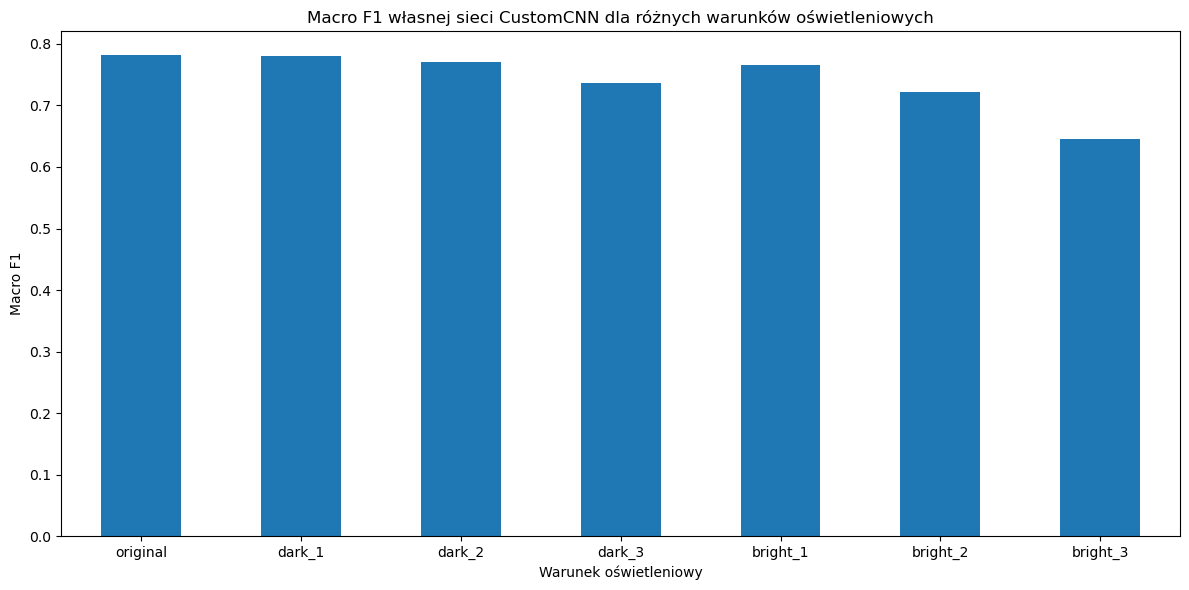

In [16]:
plot_df = (
    final_test_df[
        [
            "variant",
            "macro_f1",
        ]
    ]
)


fig, ax = plt.subplots(
    figsize=(12, 6)
)


plot_df.plot(
    x="variant",
    y="macro_f1",
    kind="bar",
    ax=ax,
    legend=False,
)


ax.set_title(
    "Macro F1 własnej sieci CustomCNN "
    "dla różnych warunków oświetleniowych"
)

ax.set_xlabel(
    "Warunek oświetleniowy"
)

ax.set_ylabel(
    "Macro F1"
)


plt.xticks(
    rotation=0
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_custom_cnn_macro_f1.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 13. Macierz pomyłek dla obrazu oryginalnego

Macierz pomyłek przedstawia rozkład poprawnych i błędnych klasyfikacji dla oryginalnych obrazów zbioru `test_final`.

In [17]:
original_test_result = next(
    result
    for result
    in test_results
    if result[
        "variant"
    ] == "original"
)


y_true_original = (
    original_test_result[
        "y_true"
    ]
)


y_pred_original = (
    original_test_result[
        "y_pred"
    ]
)


cm_original = confusion_matrix(
    y_true_original,
    y_pred_original,
    labels=list(
        range(
            len(class_codes)
        )
    ),
)


cm_original_df = pd.DataFrame(
    cm_original,
    index=class_codes,
    columns=class_codes,
)


display(
    cm_original_df
)

,A-1,A-11,A-11a,A-12a,A-14,A-15,A-16,A-17,A-18b,A-2,...,D-52,D-53,D-6,D-6b,D-7,D-8,D-9,D-tablica,G-1a,G-3
A-1,42,0,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
A-11,2,7,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
A-11a,0,0,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A-12a,0,0,0,18,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A-14,0,0,0,1,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D-8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,33,0,0,0,0
D-9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,8,0,0,0
D-tablica,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,13,0,0
G-1a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9,0


## 14. Wizualizacja macierzy pomyłek — obraz oryginalny

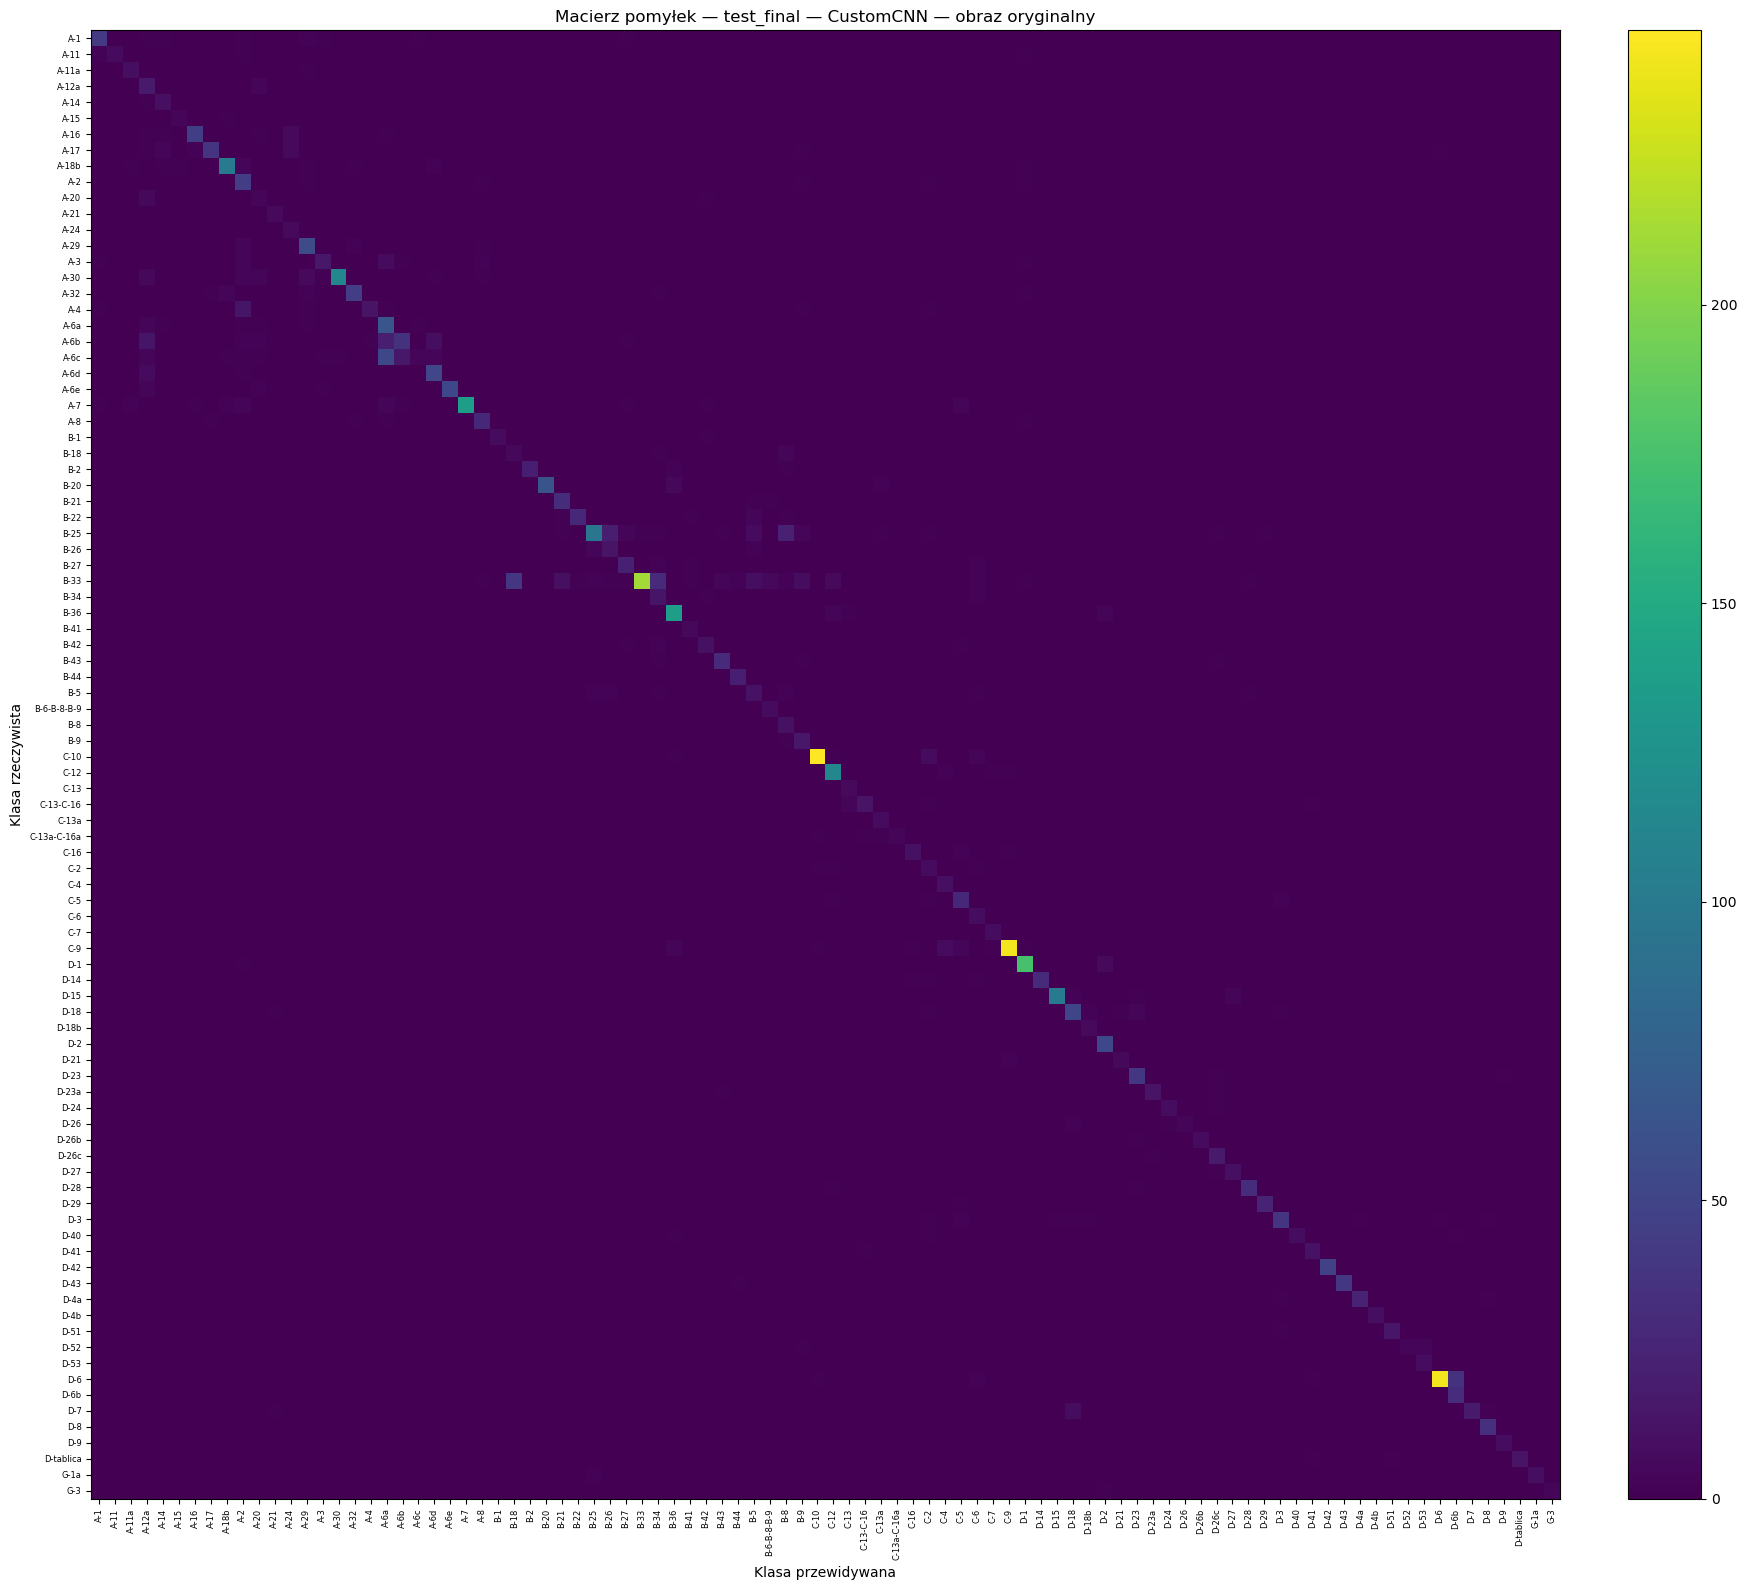

In [18]:
fig, ax = plt.subplots(
    figsize=(18, 16)
)


image = ax.imshow(
    cm_original,
    interpolation="nearest",
)


ax.set_title(
    "Macierz pomyłek — test_final — "
    "CustomCNN — obraz oryginalny"
)

ax.set_xlabel(
    "Klasa przewidywana"
)

ax.set_ylabel(
    "Klasa rzeczywista"
)


plt.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)


ax.set_xticks(
    range(
        len(class_codes)
    )
)

ax.set_yticks(
    range(
        len(class_codes)
    )
)


ax.set_xticklabels(
    class_codes,
    rotation=90,
    fontsize=6,
)

ax.set_yticklabels(
    class_codes,
    fontsize=6,
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_custom_cnn_confusion_matrix_original.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 15. Macierz pomyłek dla `dark_3`

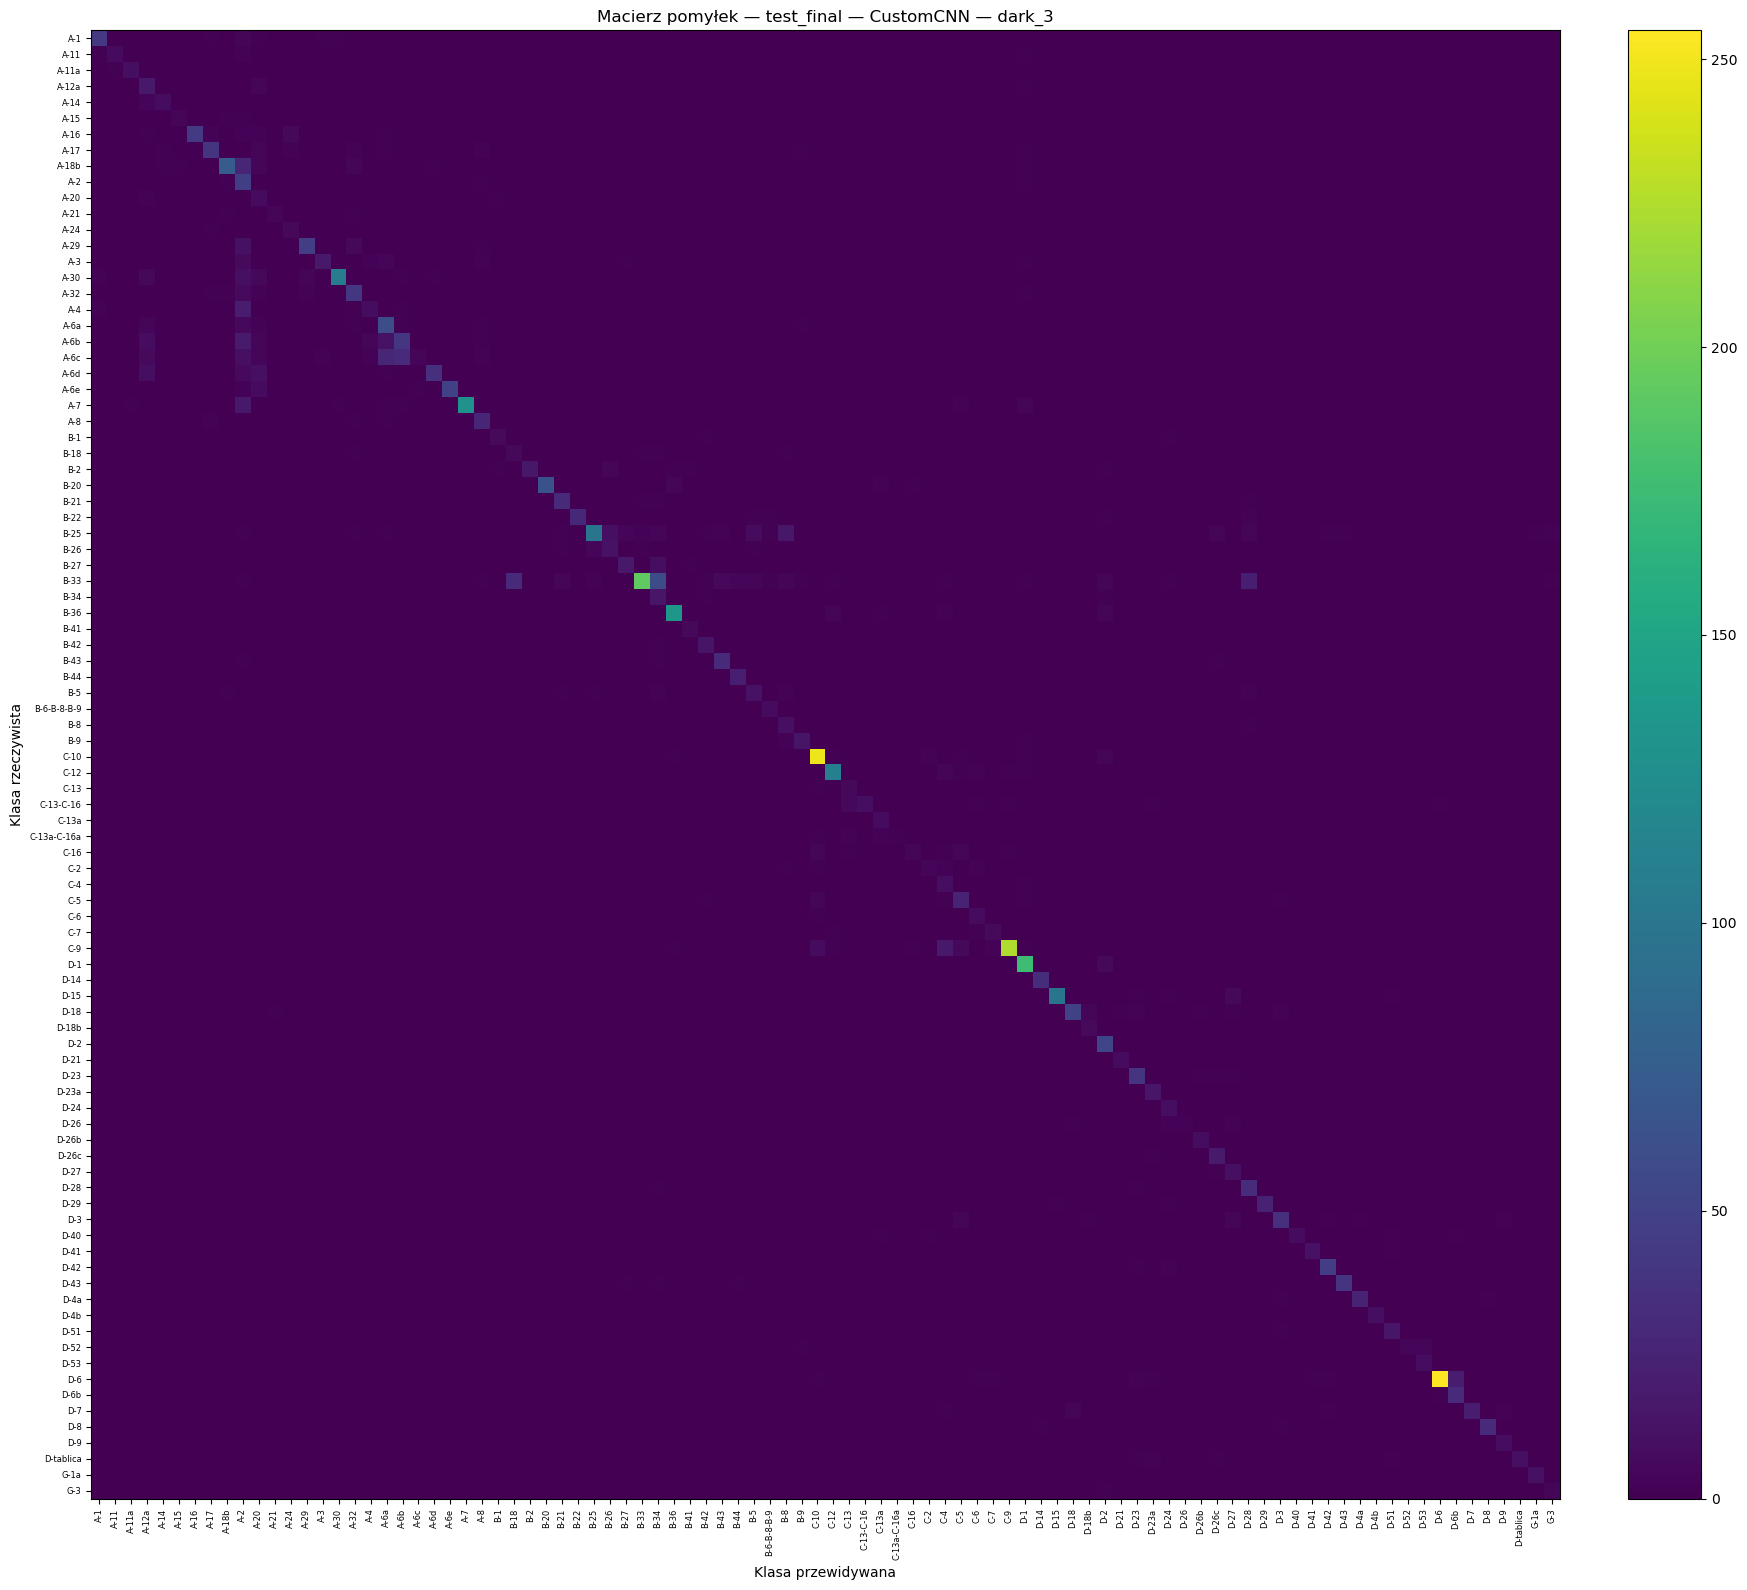

In [19]:
dark3_test_result = next(
    result
    for result
    in test_results
    if result[
        "variant"
    ] == "dark_3"
)


y_true_dark3 = (
    dark3_test_result[
        "y_true"
    ]
)


y_pred_dark3 = (
    dark3_test_result[
        "y_pred"
    ]
)


cm_dark3 = confusion_matrix(
    y_true_dark3,
    y_pred_dark3,
    labels=list(
        range(
            len(class_codes)
        )
    ),
)


fig, ax = plt.subplots(
    figsize=(18, 16)
)


image = ax.imshow(
    cm_dark3,
    interpolation="nearest",
)


ax.set_title(
    "Macierz pomyłek — test_final — "
    "CustomCNN — dark_3"
)

ax.set_xlabel(
    "Klasa przewidywana"
)

ax.set_ylabel(
    "Klasa rzeczywista"
)


plt.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)


ax.set_xticks(
    range(
        len(class_codes)
    )
)

ax.set_yticks(
    range(
        len(class_codes)
    )
)


ax.set_xticklabels(
    class_codes,
    rotation=90,
    fontsize=6,
)

ax.set_yticklabels(
    class_codes,
    fontsize=6,
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "03_custom_cnn_confusion_matrix_dark3.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 16. Najczęstsze błędne pary klas dla `dark_3`

In [20]:
error_pairs = []


for true_index, pred_index in zip(
    y_true_dark3,
    y_pred_dark3,
):

    if true_index != pred_index:

        error_pairs.append(
            {
                "true_class":
                    idx_to_class[
                        true_index
                    ],

                "predicted_class":
                    idx_to_class[
                        pred_index
                    ],
            }
        )


error_pairs_df = pd.DataFrame(
    error_pairs
)


if len(
    error_pairs_df
) > 0:

    error_pairs_summary = (
        error_pairs_df
        .groupby(
            [
                "true_class",
                "predicted_class",
            ]
        )
        .size()
        .reset_index(
            name="errors"
        )
        .sort_values(
            "errors",
            ascending=False,
        )
    )

else:

    error_pairs_summary = pd.DataFrame(
        columns=[
            "true_class",
            "predicted_class",
            "errors",
        ]
    )


display(
    error_pairs_summary.head(
        20
    )
)

,true_class,predicted_class,errors
158,B-33,B-34,59
155,B-33,B-18,31
88,A-6c,A-6b,30
30,A-18b,A-2,27
87,A-6c,A-6a,27
171,B-33,D-28,21
66,A-4,A-2,20
290,D-6,D-6b,19
77,A-6b,A-2,18
98,A-7,A-2,17


## 17. Raport wyników dla poszczególnych klas — `dark_3`

In [21]:
target_names = [
    idx_to_class[
        index
    ]
    for index
    in range(
        len(class_codes)
    )
]


dark3_report = pd.DataFrame(
    classification_report(
        y_true_dark3,
        y_pred_dark3,
        labels=list(
            range(
                len(class_codes)
            )
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


dark3_report = (
    dark3_report
    .iloc[
        :len(class_codes)
    ]
    .copy()
)


dark3_report[
    "class_code"
] = dark3_report.index


display(
    dark3_report.sort_values(
        "f1-score"
    ).head(20)
)

,precision,recall,f1-score,support,class_code
A-6c,0.750000,0.034884,0.066667,86.0,A-6c
B-18,0.138889,0.555556,0.222222,9.0,B-18
A-20,0.134615,0.700000,0.225806,10.0,A-20
B-34,0.157895,0.882353,0.267857,17.0,B-34
C-13a-C-16a,1.000000,0.166667,0.285714,6.0,C-13a-C-16a
A-4,0.500000,0.250000,0.333333,32.0,A-4
A-2,0.238579,0.940000,0.380567,50.0,A-2
C-4,0.243243,0.900000,0.382979,10.0,C-4
C-16,0.666667,0.285714,0.400000,14.0,C-16
B-8,0.285714,0.909091,0.434783,11.0,B-8


## 18. Analiza błędnych klasyfikacji względem jasności obrazu

In [22]:
brightness_column = None


for candidate in [
    "mean_brightness",
    "brightness",
]:

    if candidate in test_df.columns:

        brightness_column = (
            candidate
        )

        break


if brightness_column is None:

    raise KeyError(
        "Nie znaleziono kolumny "
        "mean_brightness ani brightness "
        "w test_df."
    )


brightness_values = (
    test_df[
        brightness_column
    ].to_numpy()
)


errors = []


for index, (
    true_index,
    pred_index,
) in enumerate(
    zip(
        y_true_dark3,
        y_pred_dark3,
    )
):

    if true_index != pred_index:

        errors.append(
            {
                "dataset_index":
                    index,

                "path":
                    test_df.iloc[
                        index
                    ][
                        "path"
                    ],

                "true_class":
                    idx_to_class[
                        true_index
                    ],

                "predicted_class":
                    idx_to_class[
                        pred_index
                    ],

                "original_brightness":
                    float(
                        brightness_values[
                            index
                        ]
                    ),
            }
        )


errors_df = pd.DataFrame(
    errors
)


display(
    errors_df.head()
)

,dataset_index,path,true_class,predicted_class,original_brightness
0,6,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-2,65.574684
1,9,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-20,129.888306
2,10,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-3,152.977585
3,20,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-30,36.004841
4,22,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-2,40.625111


## 19. Najciemniejsze błędnie sklasyfikowane obrazy

In [23]:
darkest_errors = (
    errors_df
    .sort_values(
        "original_brightness",
        ascending=True,
    )
)


display(
    darkest_errors.head(
        20
    )
)

,dataset_index,path,true_class,predicted_class,original_brightness
75,294,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-18b,A-2,11.889681
731,2721,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,C-4,D-1,12.976486
649,1986,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,B-33,B-34,14.189088
795,3378,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,D-18,D-26b,14.311814
787,3337,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,D-15,D-51,16.028507
622,1950,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,B-33,B-43,19.600332
179,698,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-4,A-2,19.664875
466,1576,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,B-25,D-42,20.073318
728,2717,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,C-2,C-4,20.214939
456,1566,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,B-25,B-8,20.755106


## 20. Wizualizacja błędnie sklasyfikowanych obrazów — `dark_3`

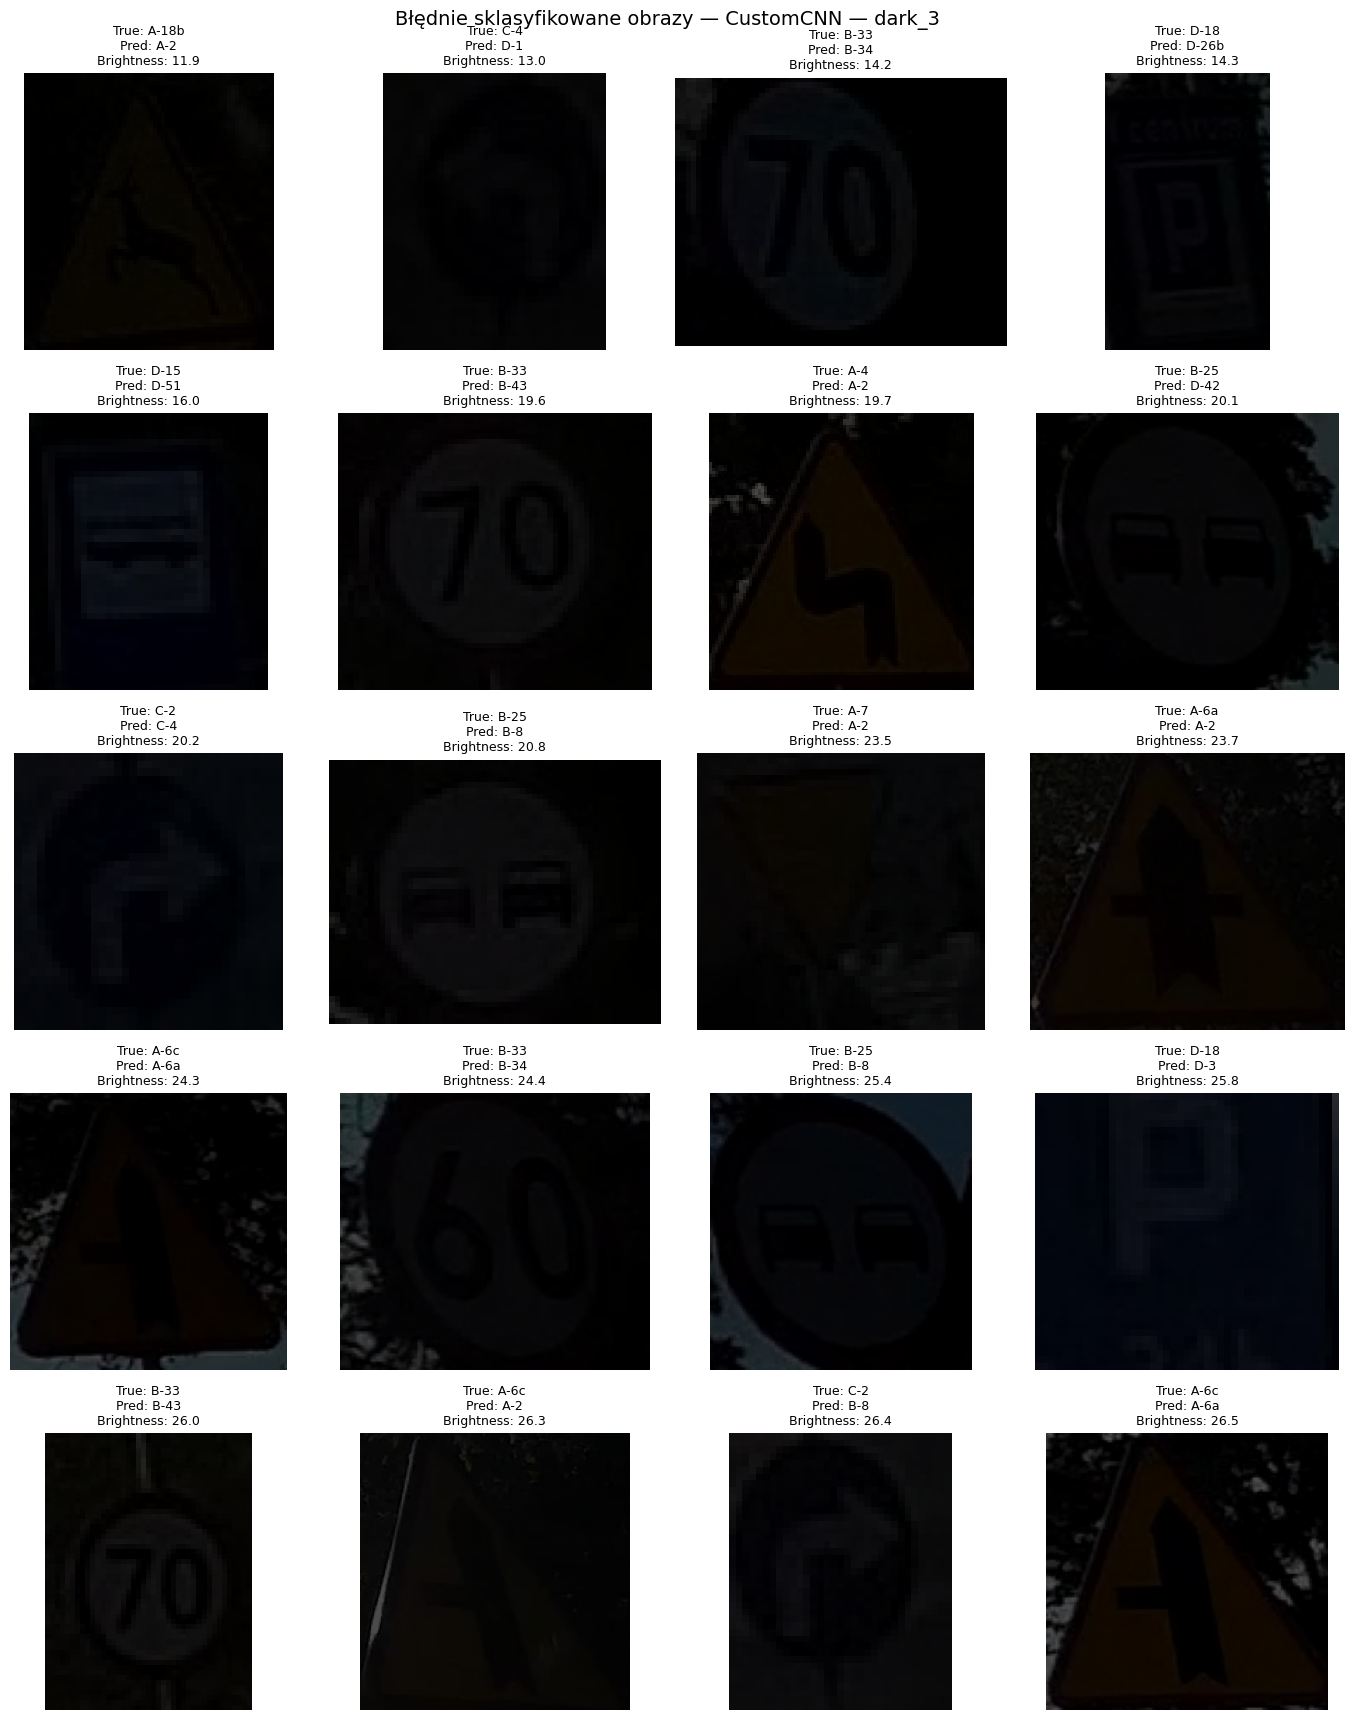

In [24]:
N_IMAGES = min(
    20,
    len(errors_df)
)


if N_IMAGES == 0:

    print(
        "Brak błędnych klasyfikacji."
    )

else:

    selected_errors = (
        errors_df
        .sort_values(
            "original_brightness"
        )
        .head(
            N_IMAGES
        )
    )


    columns = 4

    rows = math.ceil(
        N_IMAGES / columns
    )


    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            14,
            3.5 * rows,
        ),
    )


    axes = np.array(
        axes
    ).reshape(
        -1
    )


    for axis, (
        _,
        row,
    ) in zip(
        axes,
        selected_errors.iterrows(),
    ):

        image = Image.open(
            row[
                "path"
            ]
        ).convert(
            "RGB"
        )


        array = np.asarray(
            image,
            dtype=np.float32,
        )


        array = np.clip(
            array * 0.3,
            0,
            255,
        ).astype(
            np.uint8
        )


        dark_image = Image.fromarray(
            array
        )


        axis.imshow(
            dark_image
        )


        axis.set_title(
            (
                f"True: "
                f"{row['true_class']}\n"
                f"Pred: "
                f"{row['predicted_class']}\n"
                f"Brightness: "
                f"{row['original_brightness']:.1f}"
            ),
            fontsize=9,
        )


        axis.axis(
            "off"
        )


    for axis in axes[
        N_IMAGES:
    ]:

        axis.axis(
            "off"
        )


    fig.suptitle(
        "Błędnie sklasyfikowane obrazy — "
        "CustomCNN — dark_3",
        fontsize=14,
    )


    plt.tight_layout()


    fig.savefig(
        FIGURES_DIR
        / "04_custom_cnn_misclassified_dark3.png",
        dpi=250,
        bbox_inches="tight",
    )


    plt.show()

## 21. Analiza błędów dla `bright_3`

Silne prześwietlenie może prowadzić do utraty informacji o kolorze, kształcie oraz szczegółach symbolu znaku. Analiza `bright_3` pozwala określić, jak zmienia się jakość klasyfikacji po silnym zwiększeniu jasności.

In [25]:
bright3_result = next(
    result
    for result
    in test_results
    if result[
        "variant"
    ] == "bright_3"
)


y_true_bright3 = (
    bright3_result[
        "y_true"
    ]
)


y_pred_bright3 = (
    bright3_result[
        "y_pred"
    ]
)


bright3_report = pd.DataFrame(
    classification_report(
        y_true_bright3,
        y_pred_bright3,
        labels=list(
            range(
                len(class_codes)
            )
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


bright3_report = (
    bright3_report
    .iloc[
        :len(class_codes)
    ]
    .copy()
)


bright3_report[
    "class_code"
] = bright3_report.index


display(
    bright3_report.sort_values(
        "f1-score"
    ).head(20)
)

,precision,recall,f1-score,support,class_code
D-26,0.000000,0.000000,0.000000,7.0,D-26
A-6c,0.200000,0.011628,0.021978,86.0,A-6c
B-18,0.030303,0.333333,0.055556,9.0,B-18
G-3,0.057143,0.400000,0.100000,5.0,G-3
B-8,0.152542,0.818182,0.257143,11.0,B-8
B-34,0.190476,0.470588,0.271186,17.0,B-34
B-9,0.171875,0.647059,0.271605,17.0,B-9
A-20,0.235294,0.400000,0.296296,10.0,A-20
B-5,0.280000,0.333333,0.304348,21.0,B-5
C-2,0.205882,0.700000,0.318182,10.0,C-2


## 22. Szczegółowa analiza wpływu silnego prześwietlenia

In [26]:
assert len(
    test_df
) == len(
    y_true_bright3
)

assert len(
    y_true_bright3
) == len(
    y_pred_bright3
)

assert len(
    y_true_bright3
) == len(
    y_pred_original
)


print(
    "Liczba analizowanych obrazów:",
    len(test_df)
)

Liczba analizowanych obrazów: 4298


## 23. Błędy wprowadzone przez silne rozjaśnienie

In [27]:
new_bright3_errors = (
    (y_pred_original == y_true_bright3)
    &
    (y_pred_bright3 != y_true_bright3)
)


new_error_indices = np.where(
    new_bright3_errors
)[0]


new_bright3_errors_df = test_df.iloc[
    new_error_indices
].copy()


new_bright3_errors_df[
    "true_class"
] = [
    idx_to_class[
        y_true_bright3[index]
    ]
    for index
    in new_error_indices
]


new_bright3_errors_df[
    "predicted_bright3"
] = [
    idx_to_class[
        y_pred_bright3[index]
    ]
    for index
    in new_error_indices
]


new_bright3_errors_df[
    "dataset_index"
] = new_error_indices


print(
    "Poprawne w original, błędne w bright_3:",
    len(new_bright3_errors_df)
)


display(
    new_bright3_errors_df[
        [
            "dataset_index",
            "true_class",
            "predicted_bright3",
            "path",
        ]
    ].head(20)
)

Poprawne w original, błędne w bright_3: 578


,dataset_index,true_class,predicted_bright3,path
0,0,A-1,A-3,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
1,1,A-1,A-3,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
35,35,A-1,A-2,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
47,47,A-1,A-29,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
55,55,A-11,A-14,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
58,58,A-11,A-14,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
60,60,A-11,A-1,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
66,66,A-11a,A-15,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
75,75,A-12a,A-20,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
92,92,A-14,A-24,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...


## 24. Analiza błędów względem jasności obrazu

In [28]:
new_bright3_errors_df[
    "original_brightness"
] = [
    float(
        test_df.iloc[index][
            brightness_column
        ]
    )
    for index
    in new_error_indices
]


display(
    new_bright3_errors_df[
        [
            "dataset_index",
            "original_brightness",
            "true_class",
            "predicted_bright3",
        ]
    ].sort_values(
        "original_brightness",
        ascending=False,
    ).head(30)
)

,dataset_index,original_brightness,true_class,predicted_bright3
1173,1173,236.160492,A-7,A-1
3185,3185,233.919586,D-1,A-1
3180,3180,233.912567,D-1,A-1
3158,3158,231.017380,D-1,A-1
591,591,230.606155,A-30,G-3
1174,1174,226.900497,A-7,A-1
3133,3133,225.634903,D-1,A-1
3127,3127,224.919250,D-1,A-1
1137,1137,224.872604,A-7,A-1
3126,3126,224.187943,D-1,A-1


## 25. Statystyki jasności obrazów błędnie sklasyfikowanych po rozjaśnieniu

In [29]:
original_brightness_all = (
    test_df[brightness_column]
    .astype(float)
    .to_numpy()
)


bright3_correct_mask = (
    y_pred_bright3 == y_true_bright3
)


bright3_error_mask = (
    y_pred_bright3 != y_true_bright3
)


brightness_summary = pd.DataFrame(
    {
        "group": [
            "bright_3 poprawne",
            "bright_3 błędne",
            "nowe błędy po bright_3",
        ],

        "samples": [
            int(
                bright3_correct_mask.sum()
            ),

            int(
                bright3_error_mask.sum()
            ),

            int(
                new_bright3_errors.sum()
            ),
        ],

        "mean_brightness": [
            float(
                original_brightness_all[
                    bright3_correct_mask
                ].mean()
            ),

            float(
                original_brightness_all[
                    bright3_error_mask
                ].mean()
            ),

            float(
                original_brightness_all[
                    new_bright3_errors
                ].mean()
            ),
        ],

        "median_brightness": [
            float(
                np.median(
                    original_brightness_all[
                        bright3_correct_mask
                    ]
                )
            ),

            float(
                np.median(
                    original_brightness_all[
                        bright3_error_mask
                    ]
                )
            ),

            float(
                np.median(
                    original_brightness_all[
                        new_bright3_errors
                    ]
                )
            ),
        ],
    }
)


display(
    brightness_summary
)

,group,samples,mean_brightness,median_brightness
0,bright_3 poprawne,3067,109.567833,107.397453
1,bright_3 błędne,1231,122.749123,123.189919
2,nowe błędy po bright_3,578,136.820250,138.358284


## 26. Rozkład jasności obrazów błędnie sklasyfikowanych

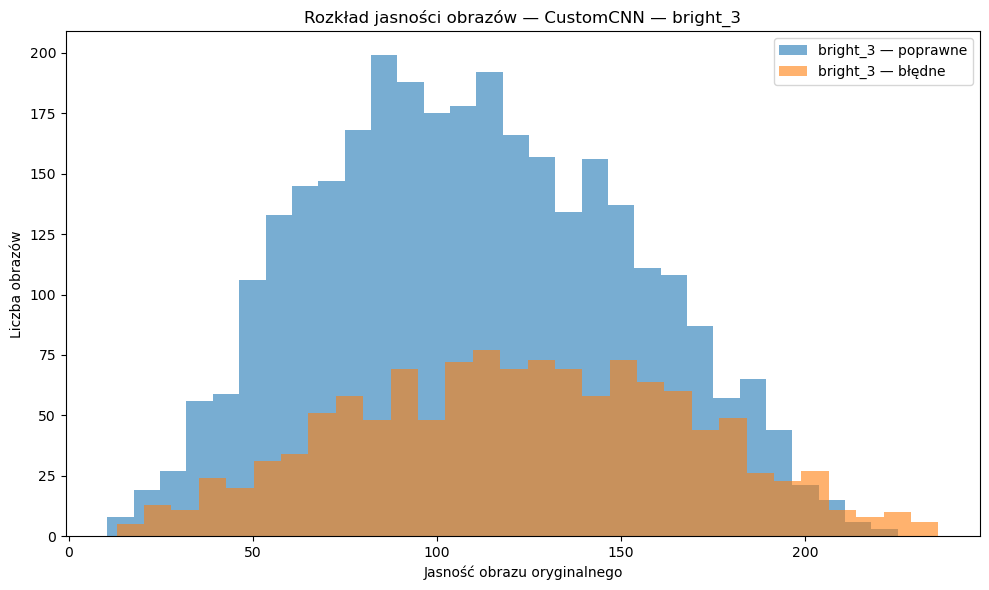

In [30]:
plt.figure(
    figsize=(10, 6)
)


plt.hist(
    original_brightness_all[
        bright3_correct_mask
    ],
    bins=30,
    alpha=0.6,
    label="bright_3 — poprawne",
)


plt.hist(
    original_brightness_all[
        bright3_error_mask
    ],
    bins=30,
    alpha=0.6,
    label="bright_3 — błędne",
)


plt.xlabel(
    "Jasność obrazu oryginalnego"
)


plt.ylabel(
    "Liczba obrazów"
)


plt.title(
    "Rozkład jasności obrazów — "
    "CustomCNN — bright_3"
)


plt.legend()


plt.tight_layout()


plt.show()

## 27. Najczęstsze pary błędnych klas dla `bright_3`

In [31]:
bright3_error_pairs = []


for true_index, pred_index in zip(
    y_true_bright3,
    y_pred_bright3,
):

    if true_index != pred_index:

        bright3_error_pairs.append(
            (
                idx_to_class[
                    true_index
                ],

                idx_to_class[
                    pred_index
                ],
            )
        )


bright3_error_pairs_df = (
    pd.DataFrame(
        bright3_error_pairs,
        columns=[
            "true_class",
            "predicted_class",
        ],
    )
    .value_counts()
    .reset_index(
        name="errors"
    )
)


display(
    bright3_error_pairs_df.head(
        20
    )
)

,true_class,predicted_class,errors
0,B-33,B-18,92
1,D-6,D-6b,61
2,B-33,B-43,38
3,A-6c,A-6a,38
4,B-25,B-8,25
5,A-30,A-2,24
6,A-6c,A-6b,21
7,B-33,B-9,21
8,C-10,C-2,19
9,D-1,A-1,16


## 28. Klasy najbardziej podatne na silne prześwietlenie

In [32]:
original_report = pd.DataFrame(
    classification_report(
        original_test_result[
            "y_true"
        ],
        original_test_result[
            "y_pred"
        ],
        labels=list(
            range(
                len(class_codes)
            )
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


bright3_report_compare = pd.DataFrame(
    classification_report(
        y_true_bright3,
        y_pred_bright3,
        labels=list(
            range(
                len(class_codes)
            )
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


class_comparison_df = pd.DataFrame(
    {
        "class_code":
            class_codes,

        "original_f1": [
            original_report.loc[
                class_code,
                "f1-score",
            ]
            for class_code
            in class_codes
        ],

        "bright3_f1": [
            bright3_report_compare.loc[
                class_code,
                "f1-score",
            ]
            for class_code
            in class_codes
        ],
    }
)


class_comparison_df[
    "f1_drop"
] = (
    class_comparison_df[
        "original_f1"
    ]
    -
    class_comparison_df[
        "bright3_f1"
    ]
)


display(
    class_comparison_df.sort_values(
        "f1_drop",
        ascending=False,
    ).head(20)
)

,class_code,original_f1,bright3_f1,f1_drop
91,G-3,0.888889,0.100000,0.788889
68,D-26,0.727273,0.000000,0.727273
25,B-1,0.933333,0.526316,0.407018
37,B-41,0.769231,0.384615,0.384615
38,B-42,0.733333,0.350000,0.383333
44,B-9,0.640000,0.271605,0.368395
39,B-43,0.882353,0.518519,0.363834
47,C-13,0.750000,0.416667,0.333333
33,B-27,0.771930,0.444444,0.327485
83,D-53,0.800000,0.476190,0.323810


## 29. Wizualizacja nowych błędów po silnym rozjaśnieniu

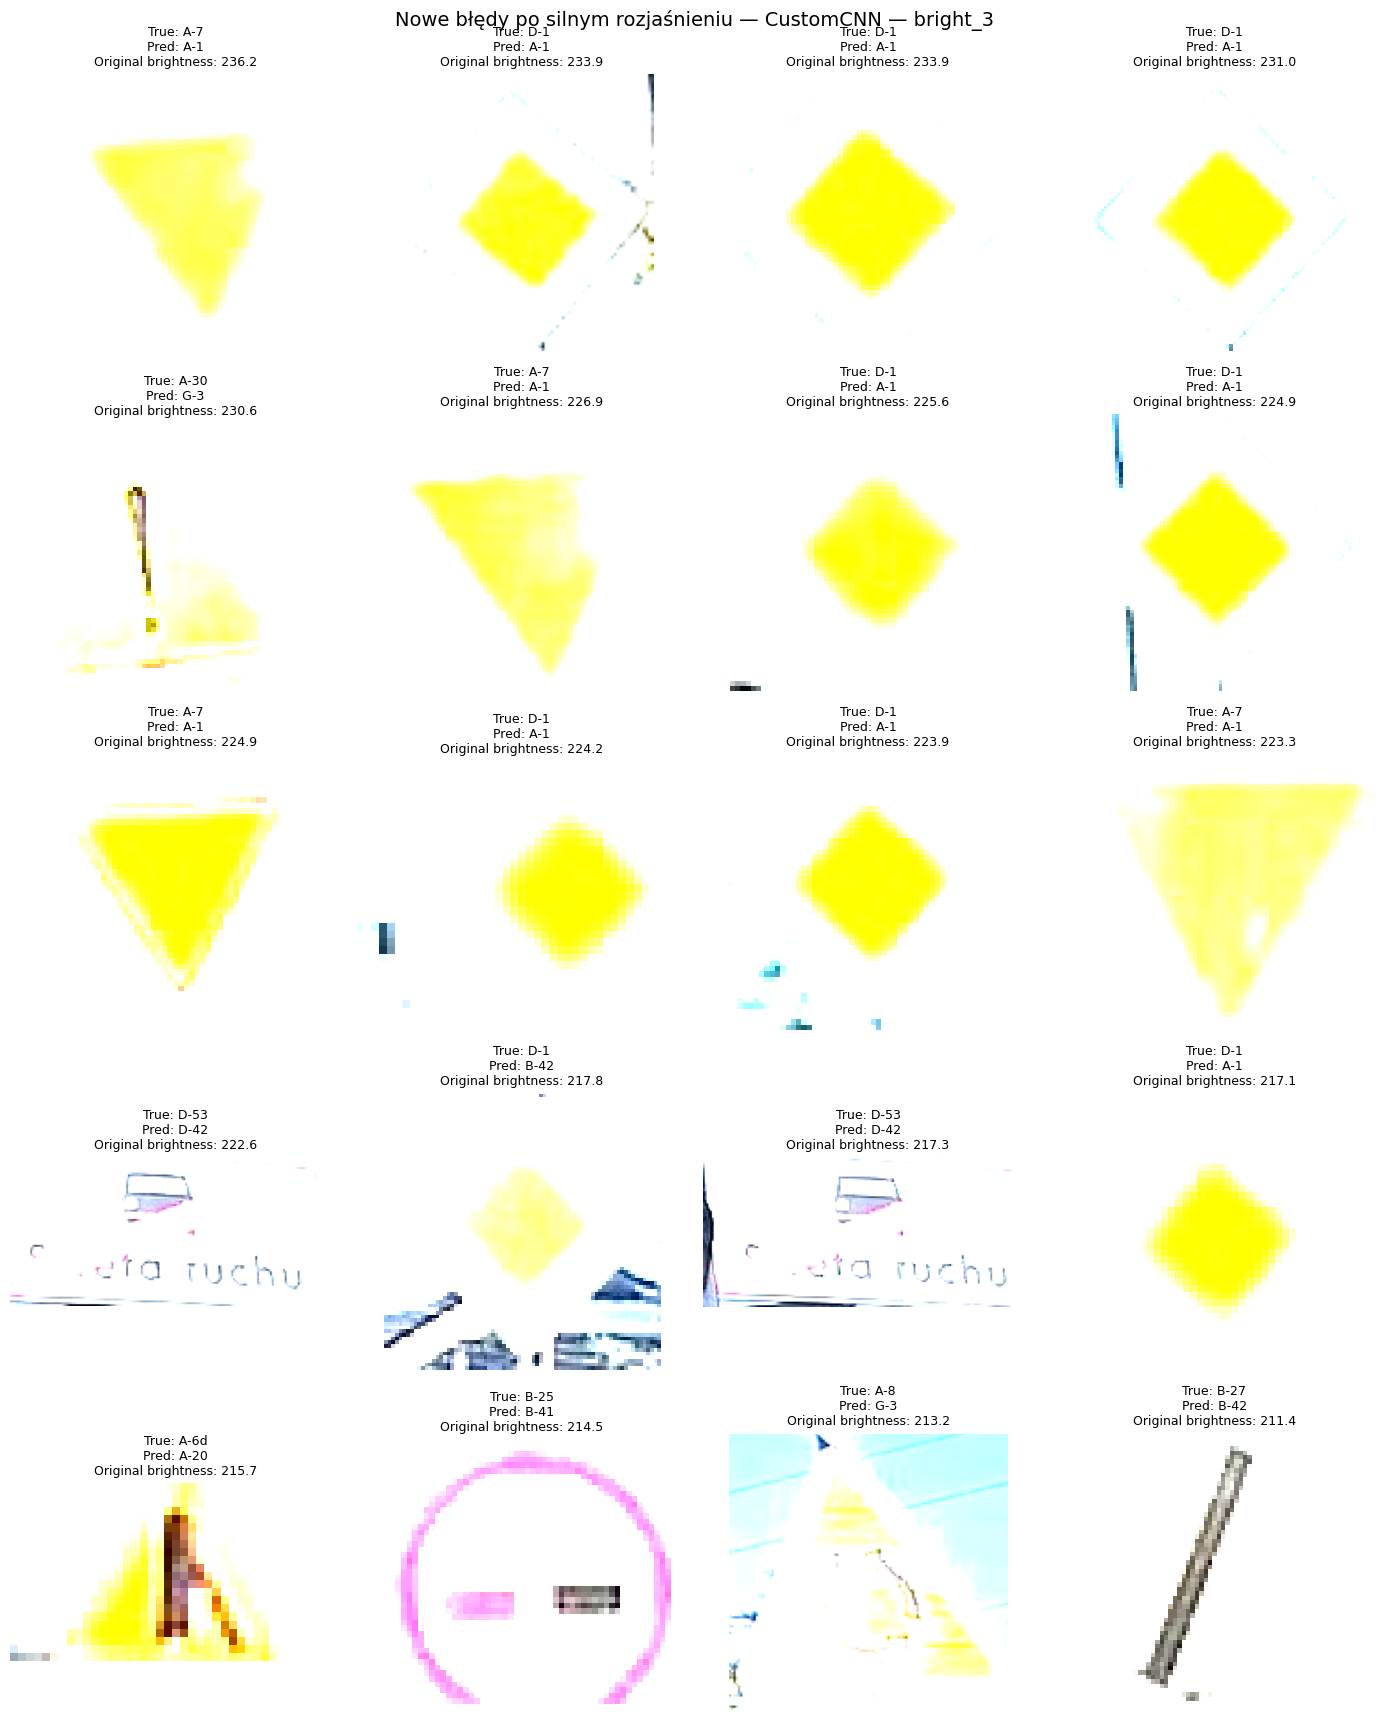

In [33]:
N_IMAGES = min(
    20,
    len(new_bright3_errors_df)
)


if N_IMAGES == 0:

    print(
        "Nie znaleziono nowych błędów "
        "wprowadzonych przez bright_3."
    )

else:

    selected_errors = (
        new_bright3_errors_df
        .sort_values(
            "original_brightness",
            ascending=False,
        )
        .head(
            N_IMAGES
        )
    )


    columns = 4

    rows = math.ceil(
        N_IMAGES / columns
    )


    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            14,
            3.5 * rows,
        ),
    )


    axes = np.asarray(
        axes
    ).reshape(-1)


    for axis, (_, row) in zip(
        axes,
        selected_errors.iterrows(),
    ):

        image = Image.open(
            row["path"]
        ).convert(
            "RGB"
        )


        bright_image = (
            ImageEnhance.Brightness(
                image
            ).enhance(
                2.0
            )
        )


        axis.imshow(
            bright_image
        )


        axis.set_title(
            (
                f"True: "
                f"{row['true_class']}\n"
                f"Pred: "
                f"{row['predicted_bright3']}\n"
                f"Original brightness: "
                f"{row['original_brightness']:.1f}"
            ),
            fontsize=9,
        )


        axis.axis(
            "off"
        )


    for axis in axes[
        N_IMAGES:
    ]:

        axis.axis(
            "off"
        )


    fig.suptitle(
        "Nowe błędy po silnym rozjaśnieniu — "
        "CustomCNN — bright_3",
        fontsize=14,
    )


    plt.tight_layout()


    fig.savefig(
        FIGURES_DIR
        / "05_custom_cnn_new_errors_bright3.png",
        dpi=250,
        bbox_inches="tight",
    )


    plt.show()

## 30. Zapis wyników końcowych

Wyniki końcowego testu, podsumowanie odporności na zaciemnienie, macierze pomyłek oraz raporty klas są zapisywane w katalogach projektu.

In [34]:
final_test_df.to_csv(
    METRICS_DIR
    / "custom_cnn_final_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)


dark_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_final_dark_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


cm_original_df.to_csv(
    METRICS_DIR
    / "custom_cnn_final_confusion_matrix_original.csv",
    encoding="utf-8-sig",
)


pd.DataFrame(
    cm_dark3,
    index=class_codes,
    columns=class_codes,
).to_csv(
    METRICS_DIR
    / "custom_cnn_final_confusion_matrix_dark3.csv",
    encoding="utf-8-sig",
)


dark3_report.to_csv(
    METRICS_DIR
    / "custom_cnn_final_dark3_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)


bright3_report.to_csv(
    METRICS_DIR
    / "custom_cnn_final_bright3_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)


errors_df.to_csv(
    METRICS_DIR
    / "custom_cnn_final_dark3_errors.csv",
    index=False,
    encoding="utf-8-sig",
)


new_bright3_errors_df.to_csv(
    METRICS_DIR
    / "custom_cnn_final_bright3_new_errors.csv",
    index=False,
    encoding="utf-8-sig",
)


brightness_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_final_bright3_brightness_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

## 31. Zapis pełnego podsumowania końcowego eksperymentu

In [35]:
final_summary = {
    "experiment":
        "final_custom_cnn_test",

    "model":
        MODEL_NAME,

    "parameters":
        total_parameters,

    "trainable_parameters":
        trainable_parameters,

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "balancing_strategy":
        BALANCING_STRATEGY,

    "loss":
        LOSS_FUNCTION,

    "gamma":
        GAMMA_VALUE,

    "brightness_range":
        BRIGHTNESS_RANGE,

    "contrast_range":
        CONTRAST_RANGE,

    "augmentation_probability":
        AUGMENTATION_PROBABILITY,

    "validation_results":
        validation_results,

    "test_results":
        final_test_df.to_dict(
            orient="records"
        ),

    "dark_summary":
        dark_summary.to_dict(
            orient="records"
        ),

    "checkpoint":
        str(
            CHECKPOINT_PATH
        ),
}


(
    METRICS_DIR
    / "custom_cnn_final_test_summary.json"
).write_text(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "experiment": "final_custom_cnn_test",
  "model": "CustomCNN",
  "parameters": 413020,
  "trainable_parameters": 413020,
  "image_size": 224,
  "batch_size": 32,
  "epochs": 20,
  "learning_rate": 0.001,
  "balancing_strategy": "weighted_sampler",
  "loss": "CrossEntropyLoss",
  "gamma": 1.5,
  "brightness_range": [
    0.3,
    1.3
  ],
  "contrast_range": [
    0.8,
    1.2
  ],
  "augmentation_probability": 0.8,
  "validation_results": {
    "accuracy": 0.8861464968152867,
    "macro_precision": 0.839980325455348,
    "macro_recall": 0.8954996843447622,
    "macro_f1": 0.846417056612751,
    "inference_time_seconds": 58.50434519999999
  },
  "test_results": [
    {
      "variant": "original",
      "factor": 1.0,
      "samples": 4298,
      "accuracy": 0.8289902280130294,
      "macro_precision": 0.7895094416199132,
      "macro_recall": 0.8373916944162944,
      "macro_f1": 0.7814440219719122,
      "inference_time_seconds": 92.0750866999997
    },
    {
      "variant": "dar

## 32. Podsumowanie wpływu silnego prześwietlenia

In [36]:
bright3_summary = {
    "model":
        MODEL_NAME,

    "original_macro_f1":
        float(
            original_test_result[
                "macro_f1"
            ]
        ),

    "bright3_macro_f1":
        float(
            bright3_result[
                "macro_f1"
            ]
        ),

    "macro_f1_drop":
        float(
            original_test_result[
                "macro_f1"
            ]
            -
            bright3_result[
                "macro_f1"
            ]
        ),

    "bright3_total_errors":
        int(
            bright3_error_mask.sum()
        ),

    "new_errors_after_brightening":
        int(
            new_bright3_errors.sum()
        ),

    "mean_original_brightness_correct":
        float(
            original_brightness_all[
                bright3_correct_mask
            ].mean()
        ),

    "mean_original_brightness_errors":
        float(
            original_brightness_all[
                bright3_error_mask
            ].mean()
        ),

    "mean_original_brightness_new_errors":
        float(
            original_brightness_all[
                new_bright3_errors
            ].mean()
        ),
}


print(
    json.dumps(
        bright3_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "model": "CustomCNN",
  "original_macro_f1": 0.7814440219719122,
  "bright3_macro_f1": 0.6450730918591464,
  "macro_f1_drop": 0.1363709301127658,
  "bright3_total_errors": 1231,
  "new_errors_after_brightening": 578,
  "mean_original_brightness_correct": 109.56783284105538,
  "mean_original_brightness_errors": 122.74912252898724,
  "mean_original_brightness_new_errors": 136.82024955749512
}
